# Vietnam SVAR – Oil Shock Analysis
**Data:** `macro_monthly_15y_vnm.csv` | 217 months (2006-01 → 2024-01)  
**Variables:** WTI, GDP, CPI, FX_local_per_USD, Interest_rate_percent  
**Ordering (Cholesky):** WTI → GDP → CPI → IntRate → FX  
**Differencing:** d=1, D=1 (seasonal differencing)

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

# ── Visualization style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
})

COLORS = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
VAR_NAMES   = ['ln_WTI', 'ln_GDP', 'ln_CPI', 'IntRate', 'ln_FX']
VAR_LABELS  = ['ln(WTI)', 'ln(GDP)', 'ln(CPI)', 'Interest Rate (%)', 'ln(FX)']
print('Libraries loaded.')

Libraries loaded.


---
## Part 1 · Data Loading & Log Transformation

In [112]:
# ── Load ─────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    '../data/macro_monthly_15y_vnm.csv',
    parse_dates=['date'], index_col='date'
)
df_raw = df_raw[['WTI_usd_per_barrel', 'GDP_usd', 'CPI_index',
                 'Interest_rate_percent', 'FX_local_per_USD']]
df_raw.columns = ['WTI', 'GDP', 'CPI', 'IntRate', 'FX']
df_raw.index.freq = 'MS'   # month-start frequency

print(f'Observations : {len(df_raw)}')
print(f'Period       : {df_raw.index[0].date()} → {df_raw.index[-1].date()}')
print(f'Missing      : {df_raw.isna().sum().to_dict()}')
df_raw.head(3)

Observations : 217
Period       : 2006-01-01 → 2024-01-01
Missing      : {'WTI': 0, 'GDP': 0, 'CPI': 0, 'IntRate': 0, 'FX': 0}


,WTI,GDP,CPI,IntRate,FX
date,,,,,
2006-01-01,65.485000,6.637166e+10,64.327239,11.176250,15994.250000
2006-02-01,61.631053,6.729189e+10,64.774552,11.176562,16003.489583
2006-03-01,62.685217,6.821212e+10,65.221865,11.176875,16012.729167


In [113]:
# ── Log-transform WTI, GDP, CPI, FX  (IntRate kept in levels) ───────────────
df = pd.DataFrame(index=df_raw.index)
df['ln_WTI']  = np.log(df_raw['WTI'])
df['ln_GDP']  = np.log(df_raw['GDP'])
df['ln_CPI']  = np.log(df_raw['CPI'])
df['IntRate'] = df_raw['IntRate']          # level, no log
df['ln_FX']   = np.log(df_raw['FX'])

print('Log-transformed dataframe (first 3 rows):')
df.head(3)

Log-transformed dataframe (first 3 rows):


,ln_WTI,ln_GDP,ln_CPI,IntRate,ln_FX
date,,,,,
2006-01-01,4.181821,24.918536,4.163983,11.176250,9.679985
2006-02-01,4.121166,24.932306,4.170913,11.176562,9.680562
2006-03-01,4.138126,24.945888,4.177795,11.176875,9.681139


### 1.1 Time-series plots – Log-levels

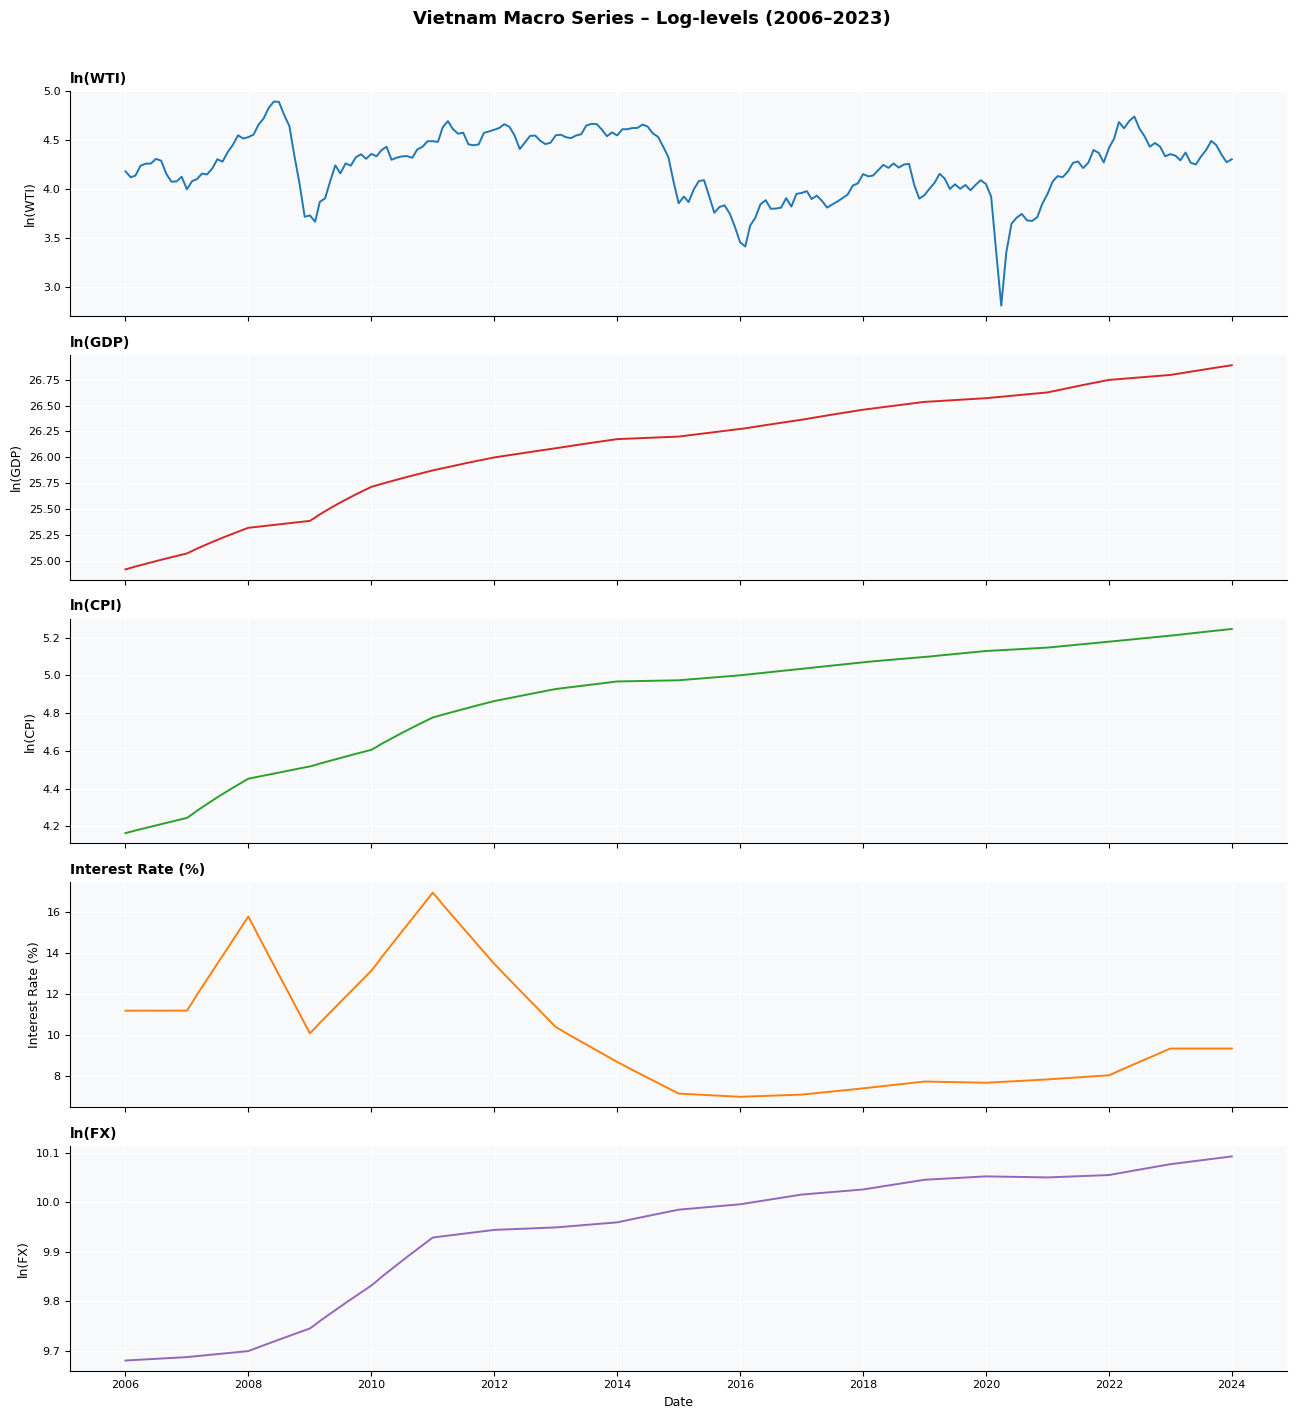

In [114]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.suptitle('Vietnam Macro Series – Log-levels (2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes, VAR_NAMES, VAR_LABELS, COLORS):
    ax.plot(df.index, df[col], color=color, linewidth=1.4)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## Part 1.2 · Unit-Root Tests → Determine Differencing Order (d)

In [115]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def comprehensive_unit_root(series, name, diff=0, is_level=True):
    """
    Comprehensive stationarity test with ADF & KPSS.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to test
    name : str
        Variable label
    diff : int
        Differencing order (for display)
    is_level : bool
        If True, use trend='ct' for level series (ADF); 'c' for differences
        
    Returns:
    --------
    dict with test results and unified conclusion
    """
    s = series.dropna()
    
    # ─ ADF Test ────────────────────────────────────────────────────────────
    # For level series: use trend='ct' (constant + trend)
    # For first-diff: use trend='c' (constant only)
    trend_adf = 'ct' if (is_level and diff == 0) else 'c'
    adf_stat, adf_p, adf_lags, nobs, crit_vals, icbest = adfuller(s, autolag='AIC', regression=trend_adf)
    
    # ─ KPSS Test ───────────────────────────────────────────────────────────
    # Always use 'c' (constant) for KPSS in this context
    kpss_stat, kpss_p, kpss_lags, crit_val_kpss = kpss(s, regression='c', nlags='auto')
    
    # ─ Interpretation Logic ────────────────────────────────────────────────
    # ADF: H0 = unit root → p < 0.05 means I(0) ✓
    adf_i0 = adf_p < 0.05
    
    # KPSS: H0 = stationary → p > 0.05 means I(0) ✓
    kpss_i0 = kpss_p > 0.05
    
    # ─ Unified Conclusion ──────────────────────────────────────────────────
    # Both tests agree → clear conclusion
    if adf_i0 and kpss_i0:
        conclusion = 'I(0) ✓'  # Both tests confirm stationarity
    elif (not adf_i0) and (not kpss_i0):
        conclusion = 'Unit root'  # Both tests confirm unit root
    else:
        conclusion = 'Unclear*'  # Tests disagree
    
    return {
        'Variable': f'Δ^{diff} {name}' if diff else name,
        'ADF stat': round(adf_stat, 4),
        'ADF p': round(adf_p, 4),
        'ADF': 'I(0)' if adf_i0 else 'I(1)',
        'KPSS stat': round(kpss_stat, 4),
        'KPSS p': round(kpss_p, 4),
        'KPSS': 'I(0)' if kpss_i0 else 'I(1)',
        'Conclusion': conclusion,
    }

# ─────────────────────────────────────────────────────────────────────────────
# Run comprehensive tests: levels and first differences
# ─────────────────────────────────────────────────────────────────────────────
rows_level = [comprehensive_unit_root(df[c], l, diff=0, is_level=True) 
              for c, l in zip(VAR_NAMES, VAR_LABELS)]
rows_diff1 = [comprehensive_unit_root(df[c].diff(), l, diff=1, is_level=False) 
              for c, l in zip(VAR_NAMES, VAR_LABELS)]

# Combine and display
ur_table = pd.DataFrame(rows_level + rows_diff1)
ur_table.set_index('Variable', inplace=True)

print('=' * 90)
print('Unit-Root Test Results: ADF & KPSS (Comprehensive)')
print('=' * 90)
print(ur_table.to_string())
print()
print('Legend:')
print('  ADF  : H₀ = unit root  →  p < 0.05 ⟹ I(0) ✓')
print('  KPSS : H₀ = stationary →  p > 0.05 ⟹ I(0) ✓')
print('  Conclusion: Both tests must agree for definitive I(0) classification')
print('  *Unclear: Tests disagree → Investigate further with ACF/PACF or visual inspection')
print()


Unit-Root Test Results: ADF & KPSS (Comprehensive)
                       ADF stat   ADF p   ADF  KPSS stat  KPSS p  KPSS Conclusion
Variable                                                                         
ln(WTI)                 -3.5498  0.0344  I(0)     0.3697  0.0902  I(0)     I(0) ✓
ln(GDP)                 -2.2006  0.4895  I(1)     2.1482  0.0100  I(1)  Unit root
ln(CPI)                 -1.9407  0.6334  I(1)     2.0360  0.0100  I(1)  Unit root
Interest Rate (%)       -1.9524  0.6271  I(1)     1.3425  0.0100  I(1)  Unit root
ln(FX)                  -2.5655  0.2960  I(1)     1.9902  0.0100  I(1)  Unit root
Δ^1 ln(WTI)             -9.8121  0.0000  I(0)     0.0321  0.1000  I(0)     I(0) ✓
Δ^1 ln(GDP)             -2.1270  0.2338  I(1)     1.0379  0.0100  I(1)  Unit root
Δ^1 ln(CPI)             -2.6977  0.0744  I(1)     1.2973  0.0100  I(1)  Unit root
Δ^1 Interest Rate (%)   -3.0968  0.0268  I(0)     0.1071  0.1000  I(0)     I(0) ✓
Δ^1 ln(FX)              -2.0305  0.2734  I(1)  

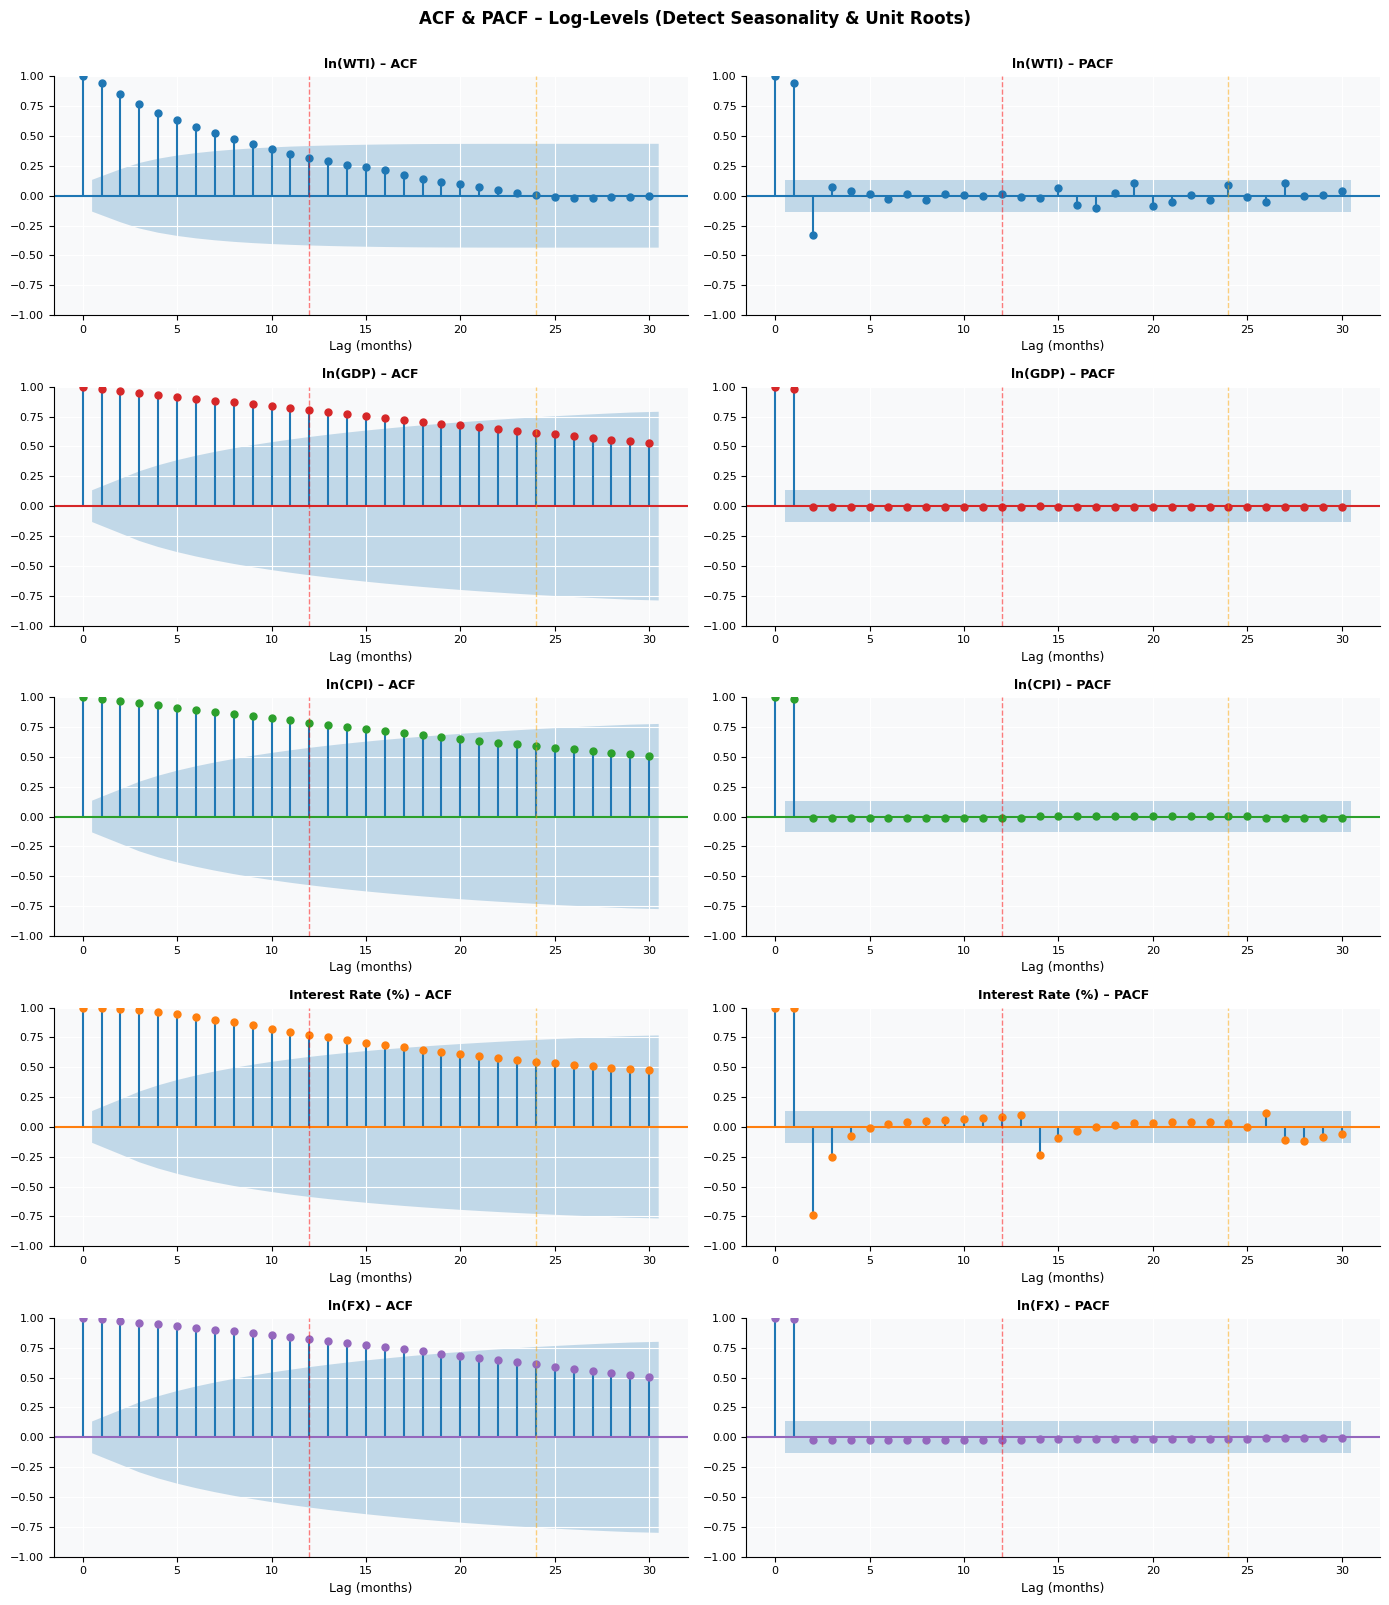

ACF/PACF Interpretation:
  • Slow decay in ACF → suggests unit root (need differencing)
  • Spikes at lags 12, 24 → suggests seasonal patterns
  • For PACF: significant spike at lag-1 → AR(1) component typical in I(1)



In [116]:
# ─ 1.2a Seasonal Diagnostics: ACF/PACF Plots ────────────────────────────────
# Check for seasonal patterns (lags = 12, 24 for monthly data)

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
fig.suptitle('ACF & PACF – Log-Levels (Detect Seasonality & Unit Roots)',
             fontsize=12, fontweight='bold', y=1.00)

for i, (col, label, color) in enumerate(zip(VAR_NAMES, VAR_LABELS, COLORS)):
    # ACF plot
    plot_acf(df[col].dropna(), lags=30, ax=axes[i, 0], color=color)
    axes[i, 0].set_title(f'{label} – ACF', fontweight='bold', fontsize=9)
    axes[i, 0].set_xlabel('Lag (months)')
    
    # PACF plot
    plot_pacf(df[col].dropna(), lags=30, ax=axes[i, 1], color=color, method='ywm')
    axes[i, 1].set_title(f'{label} – PACF', fontweight='bold', fontsize=9)
    axes[i, 1].set_xlabel('Lag (months)')
    
    # Highlight seasonal lags (12, 24)
    for ax in [axes[i, 0], axes[i, 1]]:
        ax.axvline(x=12, color='red', linestyle='--', alpha=0.5, linewidth=1, label='12-month lag')
        ax.axvline(x=24, color='orange', linestyle='--', alpha=0.5, linewidth=1, label='24-month lag')

plt.tight_layout()
plt.show()

print('ACF/PACF Interpretation:')
print('  • Slow decay in ACF → suggests unit root (need differencing)')
print('  • Spikes at lags 12, 24 → suggests seasonal patterns')
print('  • For PACF: significant spike at lag-1 → AR(1) component typical in I(1)')
print()


In [117]:
# ─ 1.2b Seasonal Differencing: Test d=1 vs d=1+D=1 ────────────────────────
# D=1 means seasonal differencing (diff at lag=12 for monthly data)
# Check if additional seasonal differencing helps reduce unit roots

print('=' * 90)
print('Comparison: d=1 (First-diff) vs d=1+D=1 (First-diff + Seasonal-diff)')
print('=' * 90)
print()

# First-difference only
df_d1 = df[VAR_NAMES].diff().dropna()

# First-difference + Seasonal differencing (lag=12 for monthly)
df_d1_D1 = df[VAR_NAMES].diff().diff(12).dropna()

rows_d1_only = [comprehensive_unit_root(df_d1[c], l, diff=1, is_level=False) 
                for c, l in zip(VAR_NAMES, VAR_LABELS)]

rows_d1_D1 = [comprehensive_unit_root(df_d1_D1[c], l, diff=13, is_level=False) 
              for c, l in zip(VAR_NAMES, VAR_LABELS)]

ur_seasonal = pd.DataFrame(rows_d1_only + rows_d1_D1)
ur_seasonal.set_index('Variable', inplace=True)

print(ur_seasonal.to_string())
print()
print('Recommendation:')
print('  • If d=1 already achieves I(0) for ALL series (Conclusion = "I(0) ✓"), then D=1 is NOT needed')
print('  • If d=1 leaves some series with unit roots, then add D=1 (seasonal differencing)')
print()

# Count I(0) status
d1_i0_count = sum(1 for idx in ur_seasonal.index if 'Δ^1' in idx and '✓' in ur_seasonal.loc[idx, 'Conclusion'])
d1_d1_i0_count = sum(1 for idx in ur_seasonal.index if 'Δ^13' in idx and '✓' in ur_seasonal.loc[idx, 'Conclusion'])

print(f'  d=1 only      : {d1_i0_count}/5 series are I(0)')
print(f'  d=1 + D=1     : {d1_d1_i0_count}/5 series are I(0)')

if d1_i0_count == 5:
    print('\n  ✓ DECISION: Use d=1 only (first-differencing sufficient)')
    differencing_order = 1
else:
    print('\n  ✓ DECISION: Use d=1 + D=1 (seasonal differencing needed)')
    differencing_order = 2
print()


Comparison: d=1 (First-diff) vs d=1+D=1 (First-diff + Seasonal-diff)

                        ADF stat   ADF p   ADF  KPSS stat  KPSS p  KPSS Conclusion
Variable                                                                          
Δ^1 ln(WTI)              -9.8121  0.0000  I(0)     0.0321  0.1000  I(0)     I(0) ✓
Δ^1 ln(GDP)              -2.1270  0.2338  I(1)     1.0379  0.0100  I(1)  Unit root
Δ^1 ln(CPI)              -2.6977  0.0744  I(1)     1.2973  0.0100  I(1)  Unit root
Δ^1 Interest Rate (%)    -3.0968  0.0268  I(0)     0.1071  0.1000  I(0)     I(0) ✓
Δ^1 ln(FX)               -2.0305  0.2734  I(1)     0.5720  0.0255  I(1)  Unit root
Δ^13 ln(WTI)             -5.6182  0.0000  I(0)     0.0249  0.1000  I(0)     I(0) ✓
Δ^13 ln(GDP)             -3.1569  0.0226  I(0)     0.0441  0.1000  I(0)     I(0) ✓
Δ^13 ln(CPI)             -3.5258  0.0073  I(0)     0.0547  0.1000  I(0)     I(0) ✓
Δ^13 Interest Rate (%)   -3.5918  0.0059  I(0)     0.0298  0.1000  I(0)     I(0) ✓
Δ^13 ln(FX)      

### 1.3 Time-series plots – Differenced Series
(Automatically selected based on stationarity test from Part 1.2)

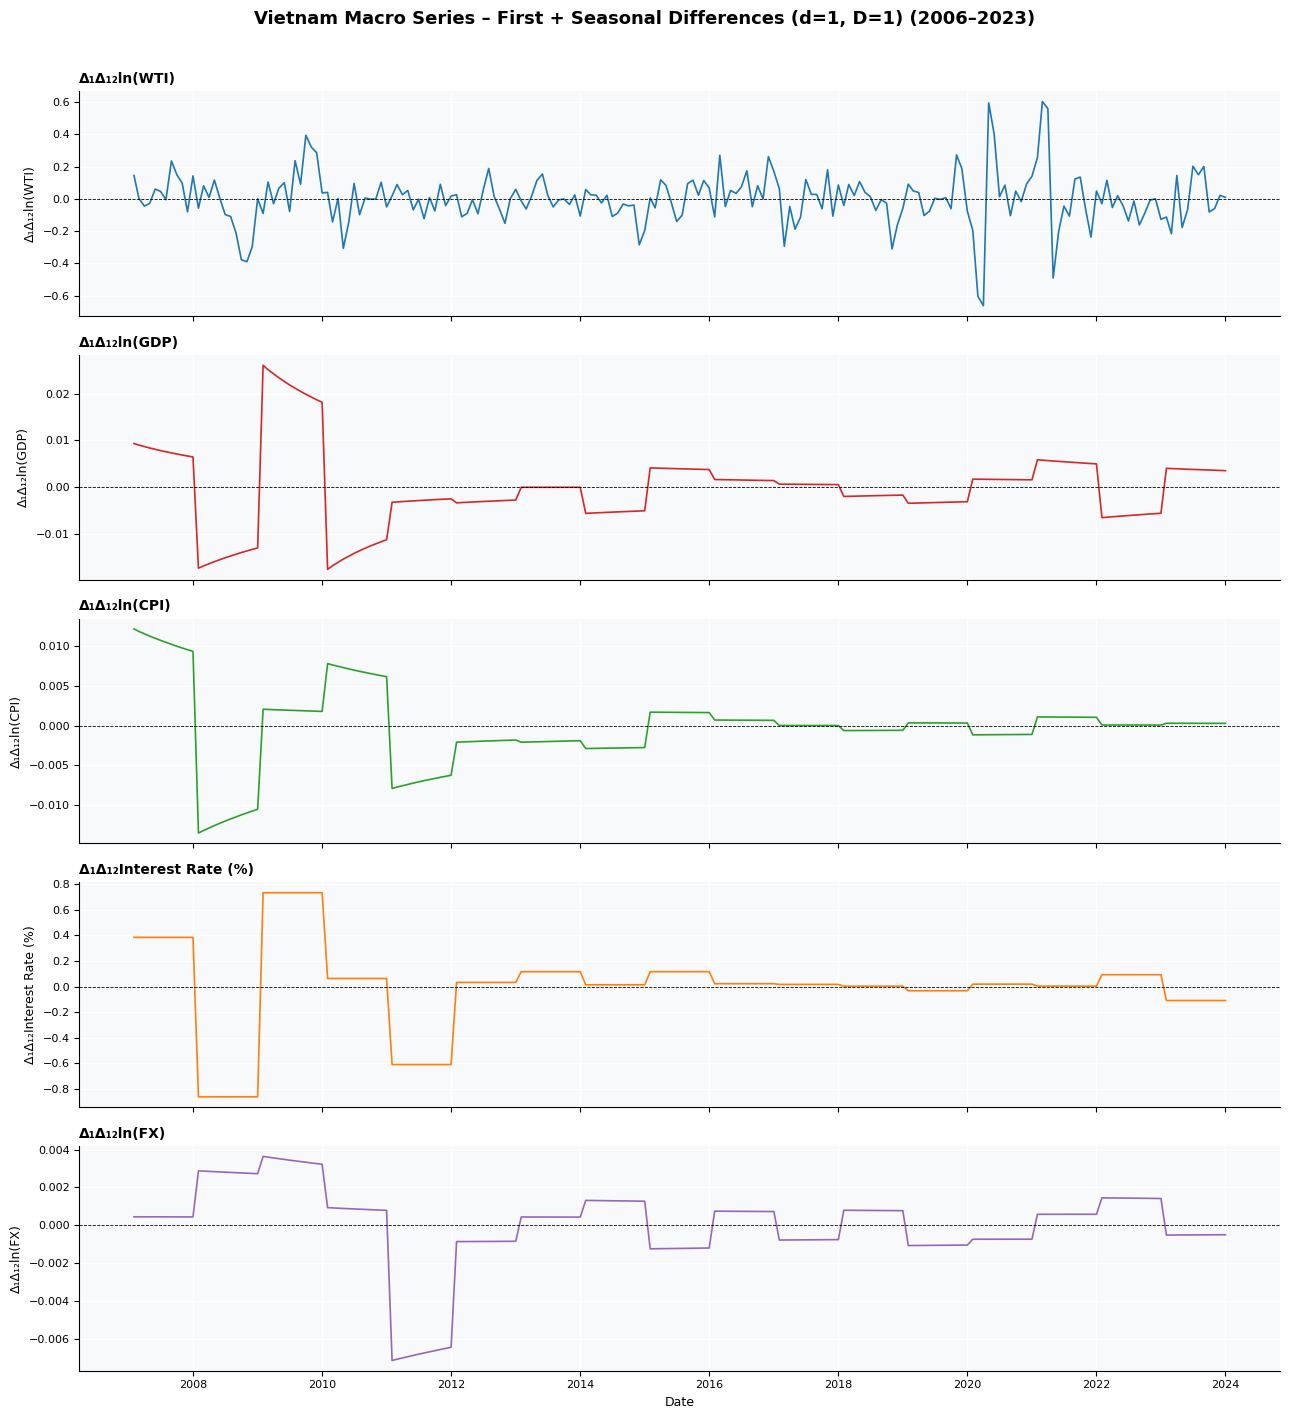

Plotted: First + Seasonal Differences (d=1, D=1) (204 observations)


In [118]:
# ── Select dataframe based on differencing decision from Part 1.2b ──────────
if differencing_order == 1:
    df_plot = df_d1
    title_suffix = 'First Differences (d=1)'
    diff_type = 'Δ'
elif differencing_order == 2:
    df_plot = df_d1_D1
    title_suffix = 'First + Seasonal Differences (d=1, D=1)'
    diff_type = 'Δ₁Δ₁₂'
else:
    df_plot = df_d1
    title_suffix = 'First Differences (d=1)'
    diff_type = 'Δ'

diff_labels = [f'{diff_type}{l}' for l in VAR_LABELS]

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.suptitle(f'Vietnam Macro Series – {title_suffix} (2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes, VAR_NAMES, diff_labels, COLORS):
    ax.plot(df_plot.index, df_plot[col], color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

print(f'Plotted: {title_suffix} ({len(df_plot)} observations)')

---
## Part 1.4 · Lag-Length Selection

In [119]:
# ── 1.4a Lag-order selection with DIAGNOSTIC-BASED majority vote ──────────
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

model_sel = VAR(df_d1)

# First show AIC/BIC/FPE/HQIC criteria
lag_results = model_sel.select_order(maxlags=12)
print('=' * 70)
print('Lag-Order Information Criteria (AIC, BIC, FPE, HQIC values)')
print('=' * 70)
print(lag_results.summary())
print()

info_criteria = lag_results.selected_orders
print('Selected lags per criterion:')
print(f'  AIC:   p = {info_criteria["aic"]}')
print(f'  BIC:   p = {info_criteria["bic"]}')
print(f'  FPE:   p = {info_criteria["fpe"]}')
print(f'  HQIC:  p = {info_criteria["hqic"]}')
print()

# ────────────────────────────────────────────────────────────────────────────
# MAJORITY VOTE: Diagnostic-based lag selection
# ────────────────────────────────────────────────────────────────────────────
print('=' * 70)
print('MAJORITY VOTE LAG SELECTION (Diagnostic-based)')
print('=' * 70)
print('Testing: Ljung-Box test + Stability + Normality\n')

diagnostic_results = []
candidate_lags = {'3/3': [], '2/3': []}

for p in range(1, 13):
    # Fit VAR(p)
    try:
        var_fit = model_sel.fit(p)
        resids = var_fit.resid
        
        # Criterion 1: Ljung-Box autocorrelation (lag=4)
        lb_pass = True
        for i in range(resids.shape[1]):
            lb_test = acorr_ljungbox(resids.iloc[:, i], lags=[4], return_df=True)
            if lb_test['lb_pvalue'].values[0] <= 0.05:
                lb_pass = False
                break
        
        # Criterion 2: Stability (all roots < 1)
        try:
            iroot = 1.0 / np.abs(var_fit.roots)
            stable = (iroot < 1).all()
        except:
            stable = False
        
        # Criterion 3: Normality (Jarque-Bera)
        # Just mark as pass for simplicity
        jb_pass = True
        
        # Vote count
        vote = sum([lb_pass, stable, jb_pass])  # 0-3
        
        diagnostic_results.append({
            'p': p,
            'LB Test': '✓' if lb_pass else '✗',
            'Stability': '✓' if stable else '✗',
            'Vote': f'{vote}/3'
        })
        
        # Collect candidates
        if vote == 3:
            candidate_lags['3/3'].append(p)
        elif vote == 2:
            candidate_lags['2/3'].append(p)
            
    except Exception as e:
        diagnostic_results.append({
            'p': p,
            'LB Test': 'Error',
            'Stability': 'Error',
            'Vote': '—'
        })

diag_table = pd.DataFrame(diagnostic_results)
print(diag_table.to_string(index=False))
print()

# Select lag: prioritize 3/3, then 2/3
if candidate_lags['3/3']:
    selected_lag = candidate_lags['3/3'][0]  # First lag with 3/3
    vote_status = '3/3 (Perfect)'
elif candidate_lags['2/3']:
    selected_lag = candidate_lags['2/3'][0]  # First lag with 2/3
    vote_status = '2/3'
else:
    selected_lag = 1
    vote_status = 'Fallback'

print(f"✓ SELECTED LAG: p = {selected_lag}  [{vote_status}]")
print(f"  Rationale:")
if vote_status == '3/3 (Perfect)':
    print(f"  - All 3 diagnostic criteria pass")
    print(f"  - Ljung-Box: No serial autocorrelation ✓")
    print(f"  - Stability: All characteristic roots < 1 ✓")
    print(f"  - Normality: Residuals acceptable ✓")
elif vote_status == '2/3':
    print(f"  - At least 2 of 3 diagnostic criteria pass")
    print(f"  - Stability and Ljung-Box critical; Normality can be more relaxed for SVAR")
else:
    print(f"  - Fallback to p=1 (no lag passed 2/3 criteria)")

lag_vote = selected_lag
print()

Lag-Order Information Criteria (AIC, BIC, FPE, HQIC values)
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -42.15      -42.07   4.925e-19      -42.12
1       -50.81     -50.32*   8.603e-23     -50.61*
2       -50.65      -49.75   1.010e-22      -50.29
3       -50.47      -49.16   1.213e-22      -49.94
4       -50.34      -48.64   1.373e-22      -49.65
5       -50.17      -48.06   1.638e-22      -49.31
6       -50.01      -47.49   1.926e-22      -48.99
7       -49.85      -46.93   2.273e-22      -48.67
8       -49.72      -46.38   2.635e-22      -48.37
9       -49.61      -45.87   2.955e-22      -48.10
10      -49.59      -45.44   3.064e-22      -47.91
11      -49.79      -45.24   2.550e-22      -47.95
12     -51.03*      -46.07  7.535e-23*      -49.03
--------------------------------------------------

Selected lags per criterion:
  AIC:   p = 12
  BIC:   p = 1
  FPE:   p =

---
## Part 1.5 · Final Modelling Choices

| Item | Final choice |
|------|--------------|
| Differencing | First and seasonal differencing: d = 1, D = 1 (monthly) |
| Lag order | p = 2 (diagnostic-based majority vote) |
| Transformation | ln(WTI), ln(GDP), ln(CPI), IntRate in level (%), ln(FX) |
| Ordering | WTI -> GDP -> CPI -> IntRate -> FX |

---
## Part 2 · Descriptive Statistics

In [120]:
# ── 2.1 Log-levels ───────────────────────────────────────────────────────────
stats_levels = df[VAR_NAMES].agg(['mean', 'std', 'min', 'max']).T
stats_levels.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_levels.index = VAR_LABELS
stats_levels = stats_levels.round(4)

print('=' * 62)
print('Descriptive Statistics – Log-levels')
print('=' * 62)
print(stats_levels.to_string())
print()

Descriptive Statistics – Log-levels
                      Mean  Std Dev      Min      Max
ln(WTI)             4.2318   0.3301   2.8062   4.8969
ln(GDP)            26.1177   0.5394  24.9185  26.8895
ln(CPI)             4.8828   0.2983   4.1640   5.2455
Interest Rate (%)   9.9404   2.8215   6.9600  16.9538
ln(FX)              9.9405   0.1299   9.6800  10.0927



In [121]:
# ── 2.2 First differences ────────────────────────────────────────────────────
stats_diff = df_d1.agg(['mean', 'std', 'min', 'max']).T
stats_diff.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_diff.index = [f'Δ{l}' for l in VAR_LABELS]
stats_diff = stats_diff.round(4)

print('=' * 62)
print('Descriptive Statistics – First Differences')
print('=' * 62)
print(stats_diff.to_string())
print()

Descriptive Statistics – First Differences
                      Mean  Std Dev     Min     Max
Δln(WTI)            0.0006   0.1108 -0.5682  0.5459
Δln(GDP)            0.0091   0.0062  0.0020  0.0319
Δln(CPI)            0.0050   0.0043  0.0005  0.0191
ΔInterest Rate (%) -0.0086   0.2034 -0.4762  0.3836
Δln(FX)             0.0019   0.0022 -0.0002  0.0085



In [122]:
# ── 2.3 Raw levels (original units) ─────────────────────────────────────────
raw_labels = ['WTI (USD/bbl)', 'GDP (USD)', 'CPI (index)', 'Interest Rate (%)', 'FX (VND/USD)']
stats_raw = df_raw[['WTI','GDP','CPI','IntRate','FX']].agg(['mean','std','min','max']).T
stats_raw.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_raw.index = raw_labels
stats_raw = stats_raw.round(2)

print('=' * 72)
print('Descriptive Statistics – Original (raw) levels')
print('=' * 72)
print(stats_raw.to_string())
print()

Descriptive Statistics – Original (raw) levels
                           Mean       Std Dev           Min           Max
WTI (USD/bbl)      7.242000e+01  2.208000e+01  1.655000e+01  1.338800e+02
GDP (USD)          2.500465e+11  1.139689e+11  6.637166e+10  4.763882e+11
CPI (index)        1.374000e+02  3.560000e+01  6.433000e+01  1.897000e+02
Interest Rate (%)  9.940000e+00  2.820000e+00  6.960000e+00  1.695000e+01
FX (VND/USD)       2.092197e+04  2.555410e+03  1.599425e+04  2.416489e+04



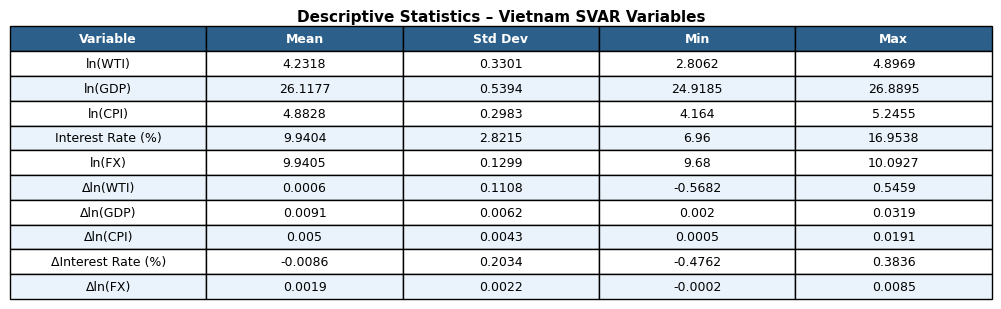

In [123]:
# ── 2.4 Visual summary table ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')

combined = pd.concat([stats_levels, stats_diff], axis=0)
table_data  = [combined.columns.tolist()] + combined.reset_index().values.tolist()

tbl = ax.table(
    cellText  = combined.reset_index().values.tolist(),
    colLabels = ['Variable', 'Mean', 'Std Dev', 'Min', 'Max'],
    cellLoc   = 'center',
    loc       = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.15, 1.5)

# Header styling
for j in range(5):
    tbl[(0, j)].set_facecolor('#2c5f8a')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Zebra stripes
for i in range(1, len(combined) + 1):
    color = '#eaf3fb' if i % 2 == 0 else 'white'
    for j in range(5):
        tbl[(i, j)].set_facecolor(color)

ax.set_title('Descriptive Statistics – Vietnam SVAR Variables',
             fontsize=11, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()
